**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4033 - Visión computacional para imágenes y video**

Tecnológico de Monterrey

Prof Gilberto Ochoa Ruiz

**Semana 7**
Harris Edge & Corner Detection

---

**Equipo 23**

|                 NOMBRE              | MATRÍCULA |
|-------------------------------------|-----------|
| Luis Fernando Caporal Montes de Oca | A01795898 |  
| David Alexis García Espinosa        | A01795178 |
| Jorge Santana Mendoza               | A01376306 |
| José Manuel Romo Peredo             | A01065270 |
| Luis Daniel Ortega Muñoz            | A01795197 |
             

# 7. Harris Edge & Corner Detection

## Table of Contents
1. [Libraries](#libraries)
2. [Color image to Grayscale conversion](#grayscale)
3. [Spatial derivative calculation](#spatial)
4. [Structure tensor setup](#tensor)
5. [Harris response calculation](#response)
6. [Find edges and corners using R](#find)
7. [Actividad](#actividad)
8. [Referencias](#referencias)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
from scipy import signal as sig
import numpy as np
#from scipy.ndimage.filters import convolve
import scipy.signal as sig
from scipy.ndimage import convolve

## 1. Color to Grayscale <a class="anchor" id="grayscale" ></a>

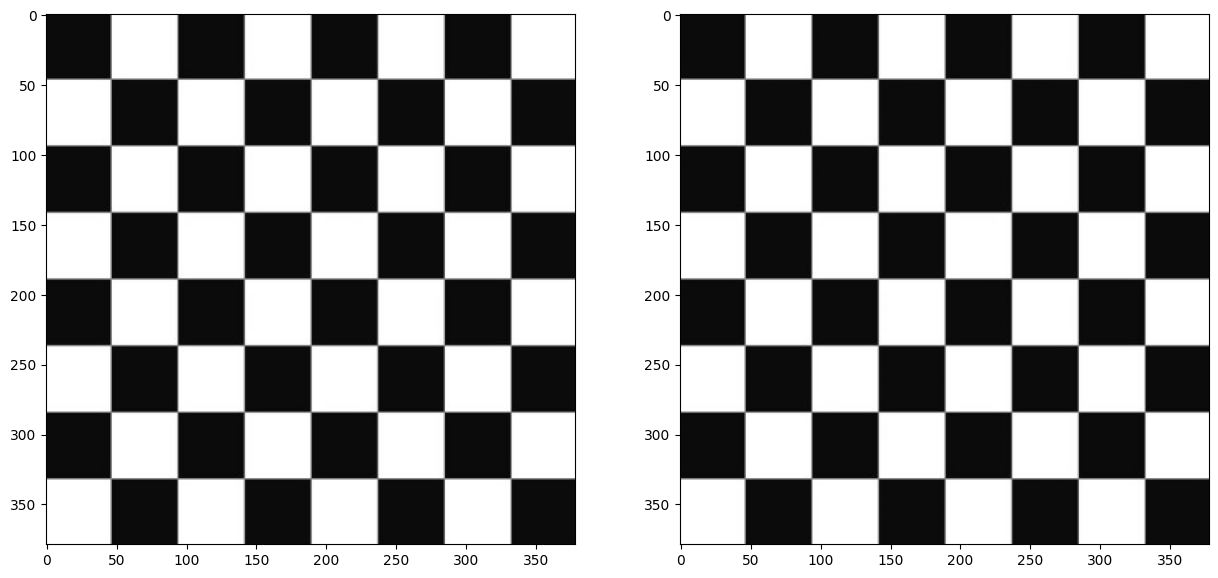

In [ ]:
img = cv2.imread('data/chessboard.jpg')
img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

## 2. Spatial derivative calculation <a class="anchor" id="spatial" ></a>

In [ ]:
def gradient_x(imggray):
    ##Sobel operator kernels.
    kernel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
    return sig.convolve2d(imggray, kernel_x, mode='same')

def gradient_y(imggray):
    kernel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    return sig.convolve2d(imggray, kernel_y, mode='same')

I_x = gradient_x(img_gray)
I_y = gradient_y(img_gray)

## 3. Structure tensor setup <a class="anchor" id="tensor" ></a>

In [ ]:
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g


Ixx = convolve(I_x**2, gaussian_kernel(3, 1))
Ixy = convolve(I_y*I_x, gaussian_kernel(3, 1))
Iyy = convolve(I_y**2, gaussian_kernel(3, 1))

## 4. Harris response calculation <a class="anchor" id="response" ></a>

In [ ]:
k = 0.05

# determinant
detA = Ixx * Iyy - Ixy ** 2

# trace
traceA = Ixx + Iyy

harris_response = detA - k * traceA ** 2

In [ ]:
img_gray.shape

(379, 378)

In [ ]:
window_size = 3
offset = window_size//2
width, height = img_gray.shape

for y in range(offset, height-offset):
    for x in range(offset, width-offset):
        Sxx = np.sum(Ixx[y-offset:y+1+offset, x-offset:x+1+offset])
        Syy = np.sum(Iyy[y-offset:y+1+offset, x-offset:x+1+offset])
        Sxy = np.sum(Ixy[y-offset:y+1+offset, x-offset:x+1+offset])

In [ ]:
#Find determinant and trace, use to get corner response
det = (Sxx * Syy) - (Sxy**2)
trace = Sxx + Syy
r = det - k*(trace**2)

## 5. Find edges and corners using R <a class="anchor" id="find" ></a>

In [ ]:
img_copy_for_corners = np.copy(img)
img_copy_for_edges = np.copy(img)

for rowindex, response in enumerate(harris_response):
    for colindex, r in enumerate(response):
        if r > 0:
            # this is a corner
            img_copy_for_corners[rowindex, colindex] = [255,0,0]
        elif r < 0:
            # this is an edge
            img_copy_for_edges[rowindex, colindex] = [0,255,0]

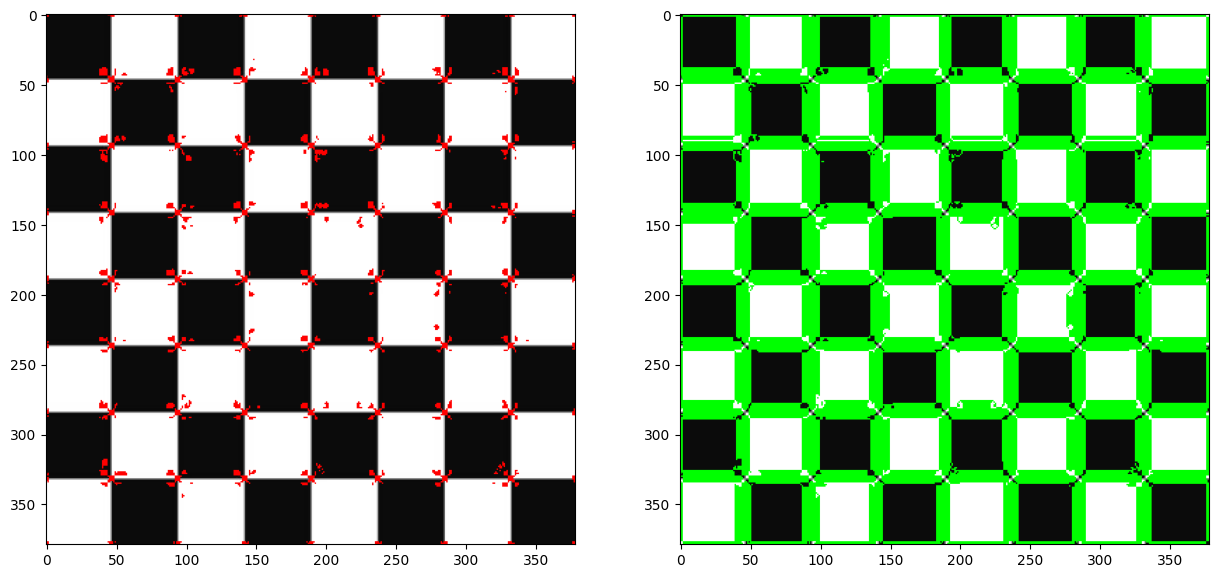

In [ ]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_copy_for_corners, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_copy_for_edges, cmap="gray")

## 6. Actividad <a class="anchor" id="actividad" ></a>

### Código anterior adaptado para procesar múltiples imágenes

Procesando imagen1_original.jpg
Esquinas detectadas: 828
Bordes detectados: 7158


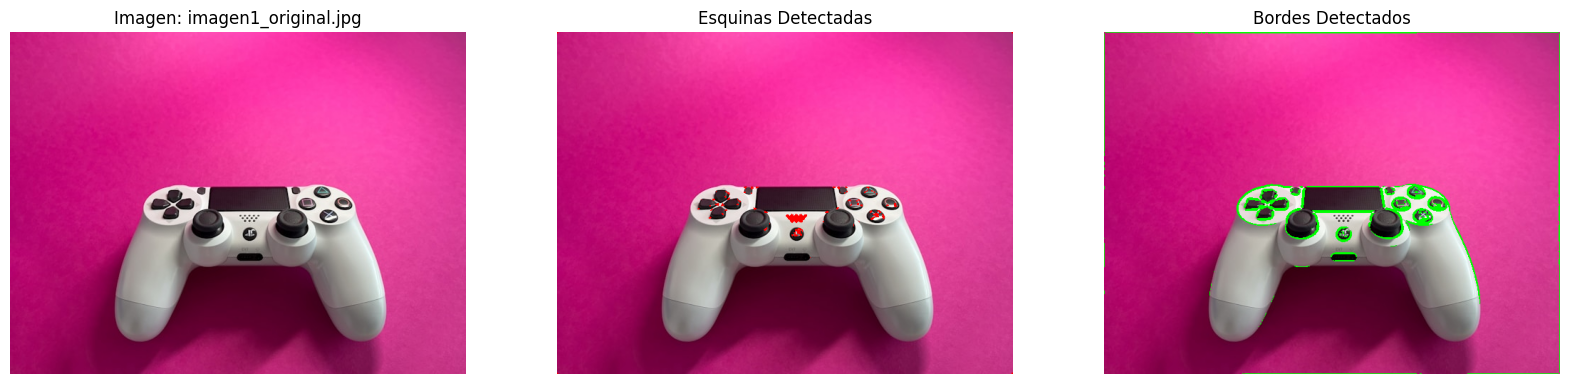

Procesando imagen1_sol.jpg
Esquinas detectadas: 982
Bordes detectados: 8426


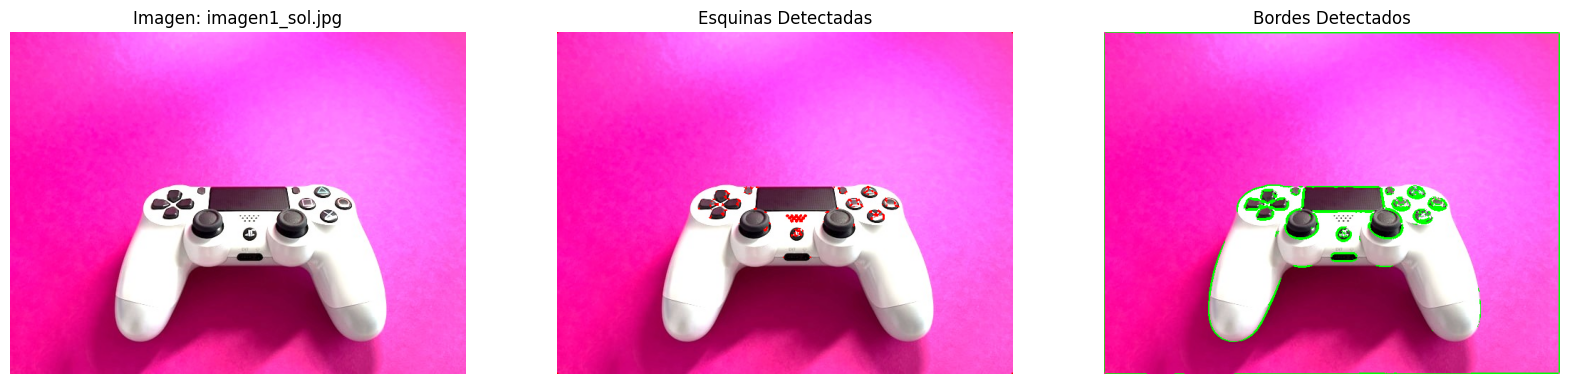

Procesando imagen2_original.jpg
Esquinas detectadas: 658
Bordes detectados: 7450


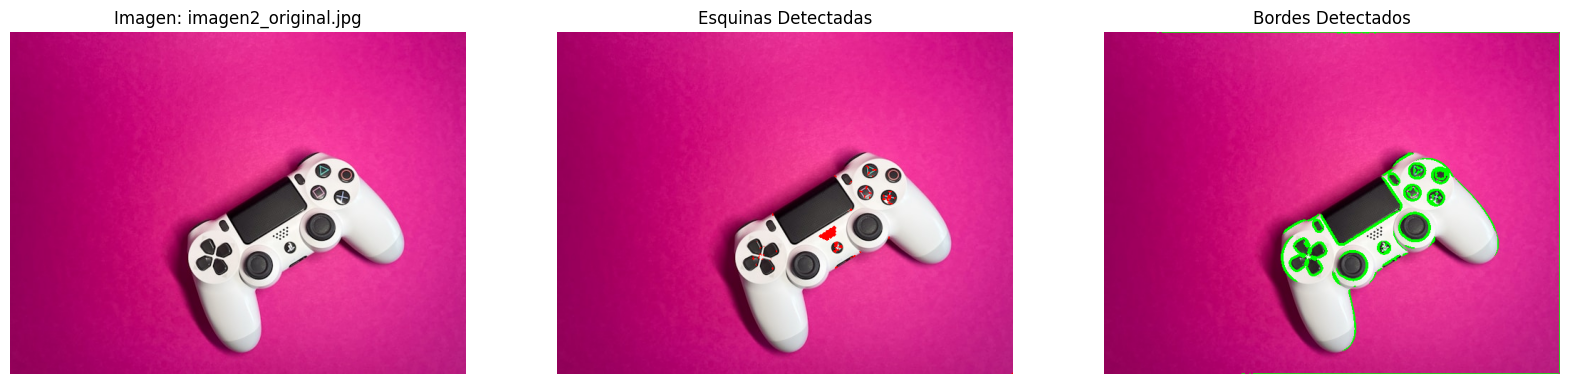

Procesando imagen2_sombra.jpg
Esquinas detectadas: 648
Bordes detectados: 7235


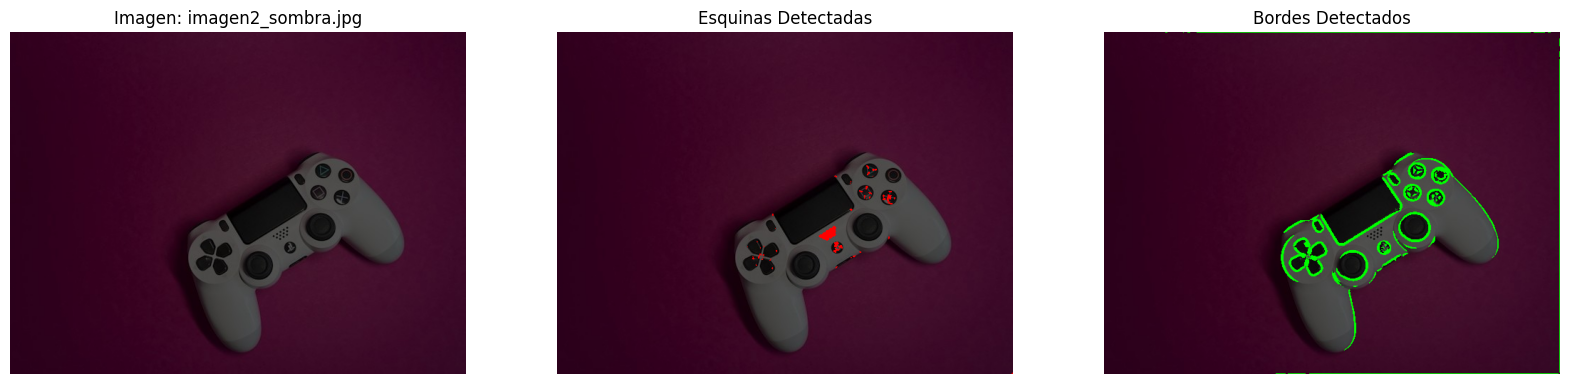

Procesando imagen3_original.jpg
Esquinas detectadas: 896
Bordes detectados: 11592


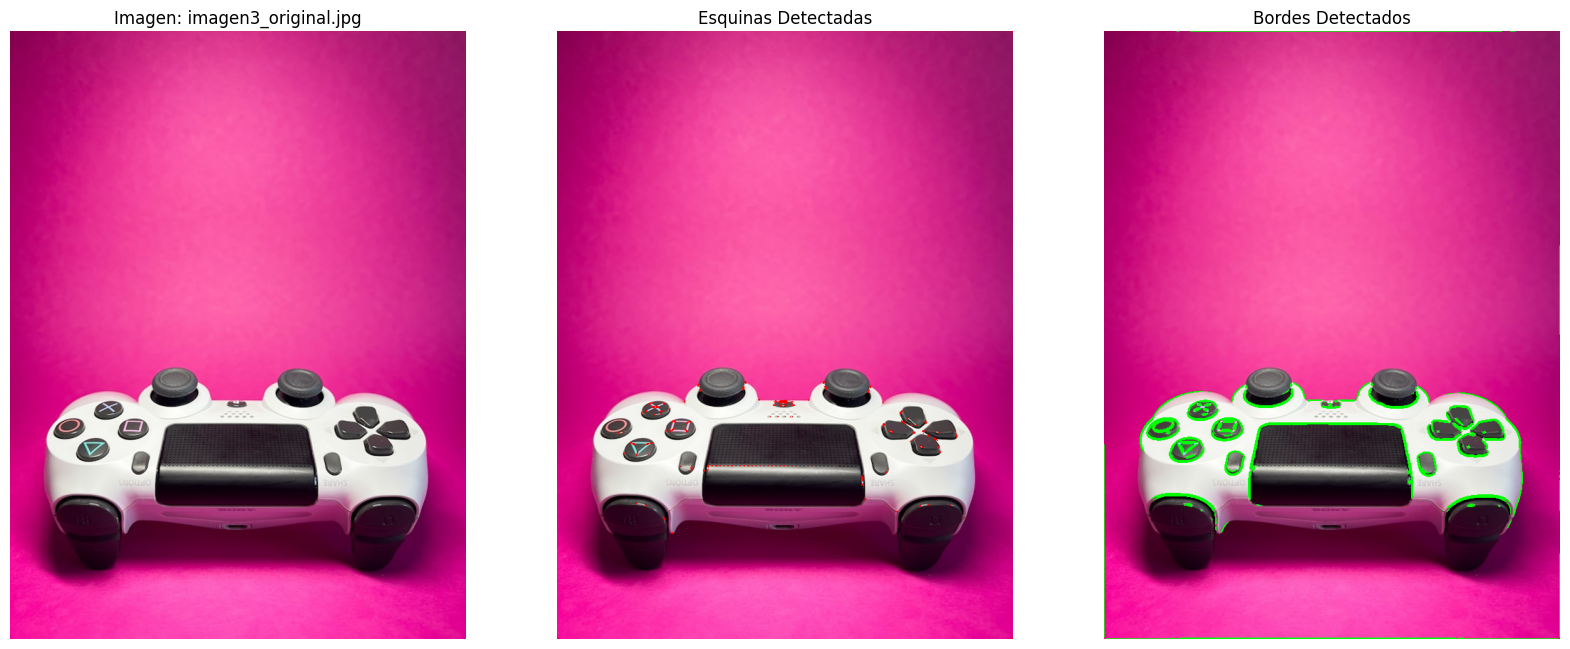

Procesando imagen3_vintage.jpg
Esquinas detectadas: 870
Bordes detectados: 13833


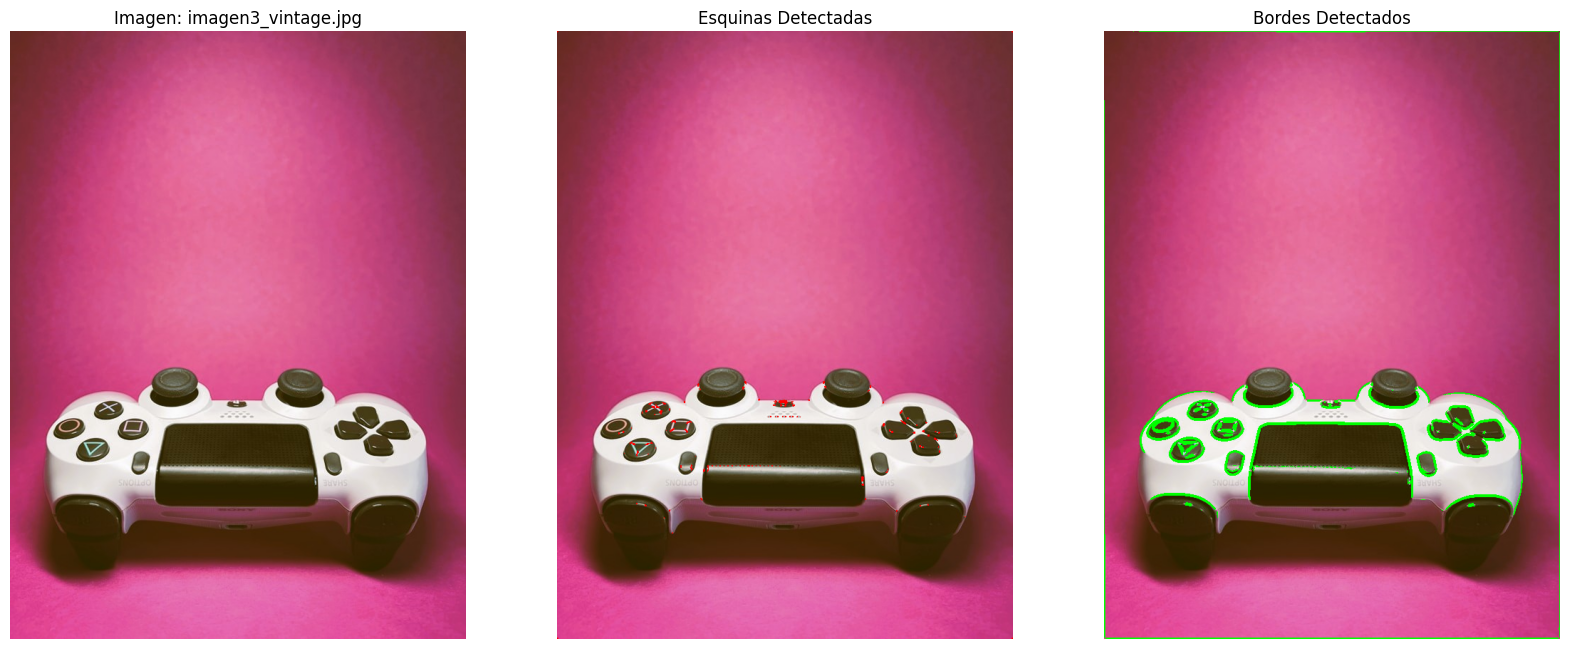

In [ ]:
def gradient_x(imggray):
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])
    return sig.convolve2d(imggray, kernel_x, mode='same')

def gradient_y(imggray):
    kernel_y = np.array([[1, 2, 1],
                         [0, 0, 0],
                         [-1, -2, -1]])
    return sig.convolve2d(imggray, kernel_y, mode='same')

def gaussian_kernel(size, sigma=1):
    size = int(size)
    x, y = np.mgrid[-size//2 + 1:size//2 +1, -size//2 +1:size//2 +1]
    g = np.exp(-((x**2 + y**2)/(2.0*sigma**2)))
    return g / g.sum()

# Lista de imágenes y sus variantes
image_files = [
    'imagen1_original.jpg', 'imagen1_sol.jpg',
    'imagen2_original.jpg', 'imagen2_sombra.jpg',
    'imagen3_original.jpg', 'imagen3_vintage.jpg'
]

for image_file in image_files:
    print(f'Procesando {image_file}')

    # 1. Convertir a escala de grises
    img = cv2.imread("data/"+image_file)
    if img is None:
        print(f'No se pudo cargar la imagen {image_file}. Saltando...')
        continue
    img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Cálculo de la derivada espacial
    I_x = gradient_x(img_gray)
    I_y = gradient_y(img_gray)

    # 3. Configuración del tensor de estructura
    Ixx = convolve(I_x**2, gaussian_kernel(3, 1))
    Ixy = convolve(I_y*I_x, gaussian_kernel(3, 1))
    Iyy = convolve(I_y**2, gaussian_kernel(3, 1))

    # 4. Cálculo de la respuesta de Harris
    k = 0.05
    detA = Ixx * Iyy - Ixy ** 2
    traceA = Ixx + Iyy
    harris_response = detA - k * traceA ** 2

    # 5. Encontrar bordes y esquinas usando R
    img_copy_for_corners = np.copy(img_color)
    img_copy_for_edges = np.copy(img_color)

    threshold_corners = np.max(harris_response) * 0.01
    threshold_edges = np.min(harris_response) * 0.01

    # Marcar esquinas y bordes
    img_copy_for_corners[harris_response > threshold_corners] = [255, 0, 0]
    img_copy_for_edges[harris_response < threshold_edges] = [0, 255, 0]

    # Contar esquinas y bordes
    num_corners = np.sum(harris_response > threshold_corners)
    num_edges = np.sum(harris_response < threshold_edges)
    print(f'Esquinas detectadas: {num_corners}')
    print(f'Bordes detectados: {num_edges}')

    # Mostrar resultados
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(img_color)
    plt.title(f'Imagen: {image_file}')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(img_copy_for_corners)
    plt.title('Esquinas Detectadas')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(img_copy_for_edges)
    plt.title('Bordes Detectados')
    plt.axis('off')
    plt.show()

### Análisis

**1. Imagen 1: Efecto de la Exposición al Sol**
* *imagen1_original.jpg*

  * Esquinas detectadas: 828

  * Bordes detectados: 7,158

* *imagen1_sol.jpg (Imagen original expuesta al sol)*

  * Esquinas detectadas: 982

  * Bordes detectados: 8,426

**Análisis:**

Comparando la imagen original con la versión expuesta al sol, se observa un incremento notable en la detección de características:

* Esquinas: Aumento de 828 a 982 (aproximadamente un 18.6% más).

* Bordes: Aumento de 7,158 a 8,426 (aproximadamente un 17.7% más).

**Interpretación:**

La luz solar intensifica el contraste y mejora la definición de la imagen, haciendo que las transiciones de intensidad sean más marcadas. Este incremento en el contraste facilita que el algoritmo detecte un mayor número de puntos de interés, tanto en las intersecciones (esquinas) como en los contornos (bordes). En esencia, la iluminación directa realza las texturas y estructuras de la escena, permitiendo una detección más precisa de sus características.



**2. Imagen 2: Efecto de la Sombra**
* *imagen2_original.jpg*

  * Esquinas detectadas: 658

  * Bordes detectados: 7,450

* *imagen2_sombra.jpg (Imagen original bajo la sombra)*

  * Esquinas detectadas: 648

  * Bordes detectados: 7,235

**Análisis:**

Al aplicar sombra se observa una ligera disminución en las detecciones:

* Esquinas: Disminución de 658 a 648 (aproximadamente un 1.5% menos).

* Bordes: Disminución de 7,450 a 7,235 (aproximadamente un 2.9% menos).

**Interpretación:**

La sombra reduce el contraste general de la imagen, suavizando las variaciones abruptas en la intensidad luminosa. Este efecto hace que el algoritmo tenga más dificultades para identificar transiciones definidas, lo que resulta en una disminución leve de esquinas y bordes. En otras palabras, la iluminación difusa de la sombra atenúa los detalles finos, afectando la detección precisa de las características geométricas.



**3. Imagen 3: Aplicación de un Filtro Vintage**
* *imagen3_original.jpg*

  * Esquinas detectadas: 896

  * Bordes detectados: 11,592

* *imagen3_vintage.jpg (Imagen original con filtro vintage aplicado)*

  * Esquinas detectadas: 870

  * Bordes detectados: 13,833

**Análisis:**

El uso del filtro vintage genera variaciones en la detección de características:

* Esquinas: Disminución de 896 a 870 (aproximadamente un 2.9% menos).

* Bordes: Aumento de 11,592 a 13,833 (aproximadamente un 19.3% más).

**Interpretación:**

El filtro vintage introduce elementos estéticos como grano, ruido y texturas que modifican la apariencia original de la imagen. Si bien estos efectos pueden suavizar algunos puntos de intersección, lo que disminuye ligeramente la detección de esquinas, al mismo tiempo generan variaciones de intensidad adicionales que el algoritmo interpreta como bordes. Así, se evidencia un aumento significativo en la cantidad de bordes detectados, resaltando cómo la alteración estética puede influir en el rendimiento de los algoritmos de detección.



**Conclusión:**


En resumen, el ejercicio demuestra que las condiciones de iluminación y la aplicación de filtros afectan de manera significativa la detección de características en las imágenes. La exposición al sol aumenta el contraste y la definición, lo que se traduce en una mayor detección de esquinas y bordes y resalta los detalles estructurales de la escena. En contraste, la sombra reduce el contraste y suaviza las transiciones de intensidad, ocasionando una leve disminución en la detección de ambas características. Por otro lado, el filtro vintage introduce ruido y texturas que incrementan notablemente la detección de bordes, aunque tiende a suavizar los puntos de intersección y a disminuir ligeramente la cantidad de esquinas detectadas. Estos hallazgos subrayan la importancia de entender cómo diferentes condiciones de iluminación y transformaciones estéticas pueden influir en los algoritmos de procesamiento de imágenes, siendo esencial ajustar sus parámetros para mantener la consistencia y precisión en aplicaciones como el reconocimiento de objetos, la navegación autónoma y el análisis de escenas.

## 7. Referencias <a class="anchor" id="referencias" ></a>

[1] Gonzalez, R. & Woods, R. (2018). Digital Image Processing.  4° Edition. Pearson.